In [ ]:
# Install necessary libraries
!pip install keras-tuner tensorflow pandas numpy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.3 MB/s eta 0:00:00


### Data Loading and Preprocessing

First, we'll load the dataset, select the target variable (`meantemp`), handle any missing values, scale the data, and prepare it into sequences suitable for an RNN/LSTM model. We'll also split the data into training and testing sets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import os
import requests

# 1. LOAD DATASET
file_name = 'LSTM_Multivariate_pollution.csv'
# Ensure the file is always downloaded to prevent using old/corrupt versions
print(f"Downloading {file_name}...")
# Updated URL to a working source for pollution.csv
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv'
r = requests.get(url, allow_redirects=True)
with open(file_name, 'wb') as f:
    f.write(r.content)
print(f"Downloaded {file_name}.")

# Load CSV and manually parse date columns
df = pd.read_csv(file_name)

# Manually combine date columns to create a datetime index
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.set_index('date')

# Drop the original date/time columns and the 'No' column
df.drop(['No', 'year', 'month', 'day', 'hour'], axis=1, inplace=True)

# Rename 'cbwd' to 'wnd_dir' to match the original code's expectation
df.rename(columns={'cbwd': 'wnd_dir'}, inplace=True)

# Reorder columns to ensure 'pm2.5' (the target variable) is the first feature
# This ensures it becomes 'var1' in the supervised learning step
cols = df.columns.tolist()
cols.remove('pm2.5')
df = df[['pm2.5'] + cols]

# 2. DATA PREPROCESSING

# Encode categorical wind direction
encoder = LabelEncoder()
df['wnd_dir'] = encoder.fit_transform(df['wnd_dir'])

# Convert series to supervised learning format
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = data.shape[1]
    df_temp = pd.DataFrame(data)
    cols, names = list(), list()

    # Input sequence (t-n ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df_temp.shift(i))
        names += [f'var{j+1}(t-{i})' for j in range(n_vars)]

    # Forecast sequence (t)
    for i in range(0, n_out):
        cols.append(df_temp.shift(-i))
        if i == 0:
            names += [f'var{j+1}(t)' for j in range(n_vars)]
        else:
            names += [f'var{j+1}(t+{i})' for j in range(n_vars)]

    agg = pd.concat(cols, axis=1)
    agg.columns = names

    if dropnan:
        agg.dropna(inplace=True)

    return agg

# Scaling
values = df.values.astype('float32')
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

# Convert to supervised
n_lag = 1 # Number of previous time steps to use as input
reframed = series_to_supervised(scaled, n_lag, 1)

# Drop unwanted columns
# Based on the typical `pollution.csv` structure and original code's intent (dropping all except var1(t)),
# the last column 'var1(t)' (which is 'pm2.5') should be kept.
# The original code's `reframed.drop(reframed.columns[[9,10,11,12,13,14,15]], axis=1, inplace=True)`
# is designed to keep 'var1(t)' as the target, assuming 'var1' is 'pm2.5' and there are 8 input features.
# So, the columns var2(t) to var8(t) should be dropped. With 8 features, these are indices 9 to 15 (0-indexed).
reframed.drop(reframed.columns[[9,10,11,12,13,14,15]], axis=1, inplace=True)

# 3. TRAIN-TEST SPLIT
values = reframed.values
n_train_hours = 365 * 24 * 4

train = values[:n_train_hours, :]
test = values[n_train_hours:, :]

train_X, train_y = train[:, :-1], train[:, -1]
test_X, test_y = test[:, :-1], test[:, -1]

# Reshape for LSTM
train_X = train_X.reshape((train_X.shape[0], n_lag, train_X.shape[1] // n_lag))
test_X = test_X.reshape((test_X.shape[0], n_lag, test_X.shape[1] // n_lag))

print(f"X_train shape: {train_X.shape}")
print(f"y_train shape: {train_y.shape}")
print(f"X_test shape: {test_X.shape}")
print(f"y_test shape: {test_y.shape}")

Downloaded LSTM_Multivariate_pollution.csv.
X_train shape: (35040, 1, 8)
y_train shape: (35040,)
X_test shape: (6503, 1, 8)
y_test shape: (6503,)


### RNN/LSTM Model without Hyperparameter Tuning

Now, let's build and train a basic LSTM model with fixed parameters. We'll then evaluate its performance by visualizing the predicted versus actual values.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting training...
Epoch 1/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0388 - val_loss: 0.0385
Epoch 2/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0196 - val_loss: 0.0159
Epoch 3/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0167 - val_loss: 0.0128
Epoch 4/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0158 - val_loss: 0.0116
Epoch 5/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0152 - val_loss: 0.0121
Epoch 6/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0150 - val_loss: 0.0115
Epoch 7/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0148 - val_loss: 0.0119
Epoch 8/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0147 - val_loss: 0.0114
Epoch 9/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0147 - val_loss: 0.0115
Epoch 10/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0146 - val_loss: 0.0112
Epoch 11/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0145 - val_loss: 0.0114
Epoch 12/20
487/487 ━━━━━━━━━━━

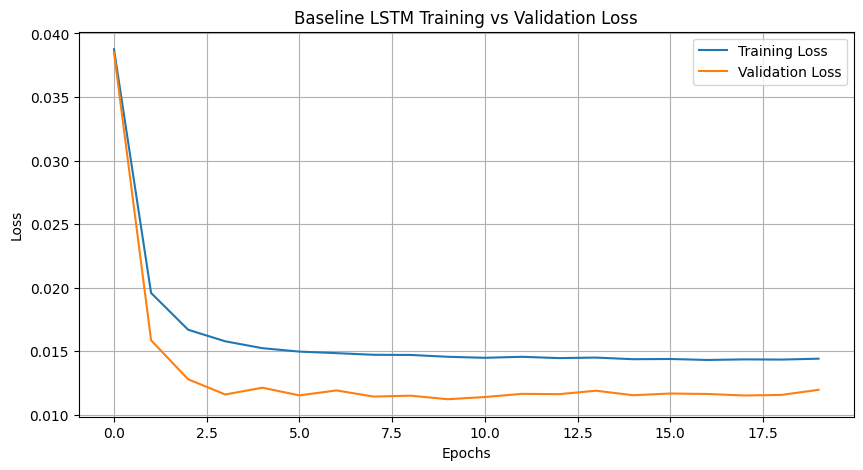

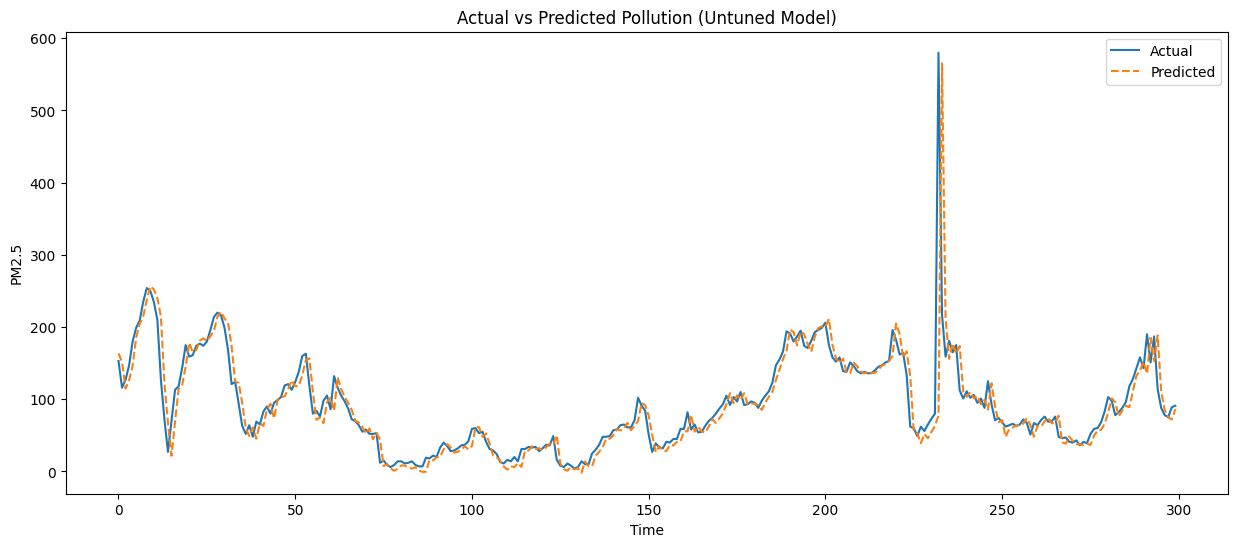

In [ ]:
# 4. MODEL
model = Sequential()
model.add(LSTM(50, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(loss='mae', optimizer='adam')

# 5. TRAINING
print("Starting training...")
history = model.fit(
    train_X, train_y,
    epochs=20,
    batch_size=72,
    validation_data=(test_X, test_y),
    verbose=1,
    shuffle=False
)

# 6. EVALUATION
# Predict on test set
yhat = model.predict(test_X)

# Predict on train set for training RMSE
train_yhat = model.predict(train_X)

test_X_reshaped = test_X.reshape((test_X.shape[0], test_X.shape[2]))
train_X_reshaped = train_X.reshape((train_X.shape[0], train_X.shape[2]))

# Inverse scaling for test predictions
inv_yhat = np.concatenate((yhat, test_X_reshaped[:, 1:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)[:, 0]

# Inverse scaling for actual test values
test_y_reshaped = test_y.reshape((len(test_y), 1))
inv_y = np.concatenate((test_y_reshaped, test_X_reshaped[:, 1:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)[:, 0]

# Inverse scaling for train predictions
inv_train_yhat = np.concatenate((train_yhat, train_X_reshaped[:, 1:]), axis=1)
inv_train_yhat = scaler.inverse_transform(inv_train_yhat)[:, 0]

# Inverse scaling for actual train values
train_y_reshaped = train_y.reshape((len(train_y), 1))
inv_train_y = np.concatenate((train_y_reshaped, train_X_reshaped[:, 1:]), axis=1)
inv_train_y = scaler.inverse_transform(inv_train_y)[:, 0]

# Metrics
test_rmse_untuned = np.sqrt(mean_squared_error(inv_y, inv_yhat))
train_rmse_untuned = np.sqrt(mean_squared_error(inv_train_y, inv_train_yhat))

print("\n--- PERFORMANCE METRICS (Untuned Model) ---")
print(f"Train RMSE: {train_rmse_untuned:.4f}")
print(f"Test RMSE: {test_rmse_untuned:.4f}")

# 7. VISUALS

# Loss graph
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Baseline LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Prediction graph
plt.figure(figsize=(15, 6))
plt.plot(inv_y[:300], label='Actual')
plt.plot(inv_yhat[:300], label='Predicted', linestyle='--')
plt.title('Actual vs Predicted Pollution (Untuned Model)')
plt.xlabel('Time')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

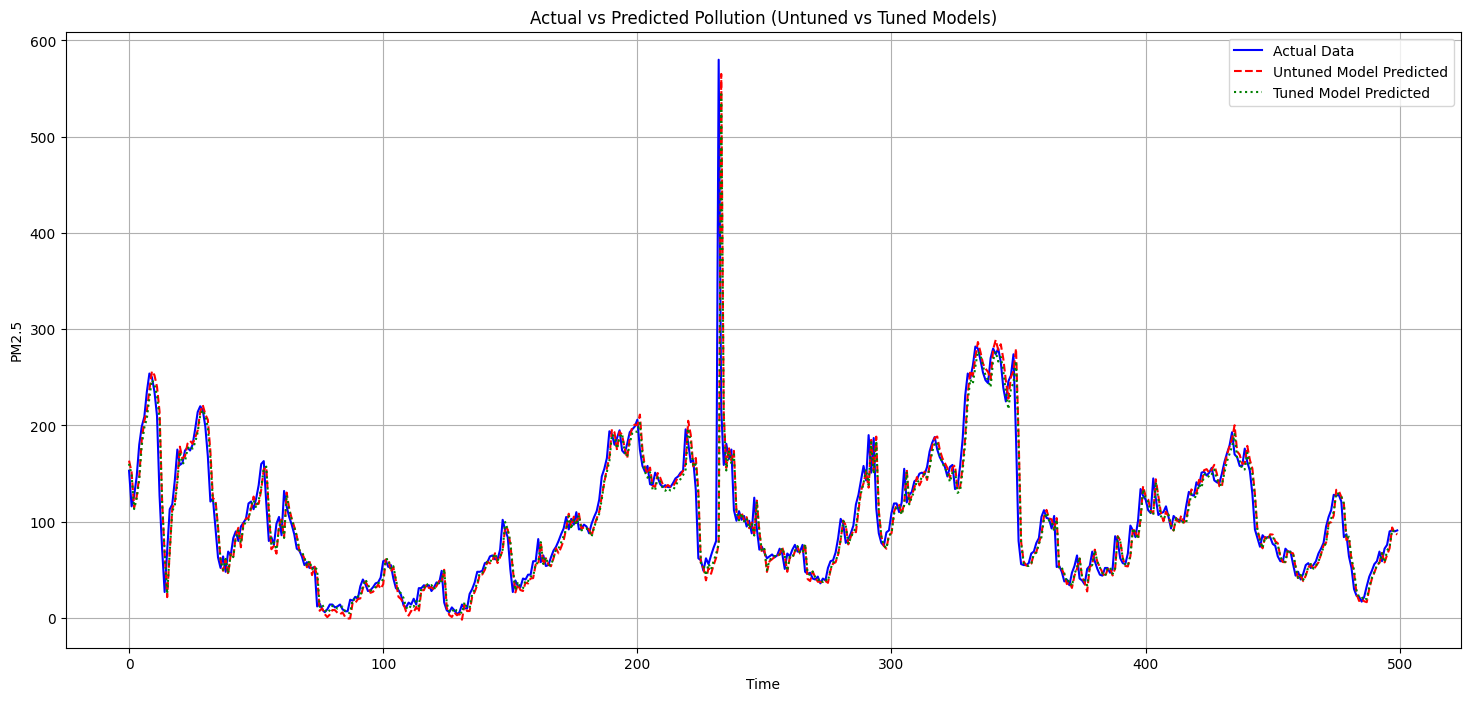

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 8))
plt.plot(inv_y[:500], label='Actual Data', color='blue') # Limiting to first 500 points for clarity
plt.plot(inv_yhat[:500], label='Untuned Model Predicted', linestyle='--', color='red')
plt.plot(inv_test_predict_tuned[:500], label='Tuned Model Predicted', linestyle=':', color='green')

plt.title('Actual vs Predicted Pollution (Untuned vs Tuned Models)')
plt.xlabel('Time')
plt.ylabel('PM2.5')
plt.legend()
plt.grid(True)
plt.show()

### Tuned Model Loss Visualization

This plot shows the training and validation loss curves for the best model found by Keras Tuner, after its final training phase. This helps to assess its learning progression and identify potential overfitting or underfitting.

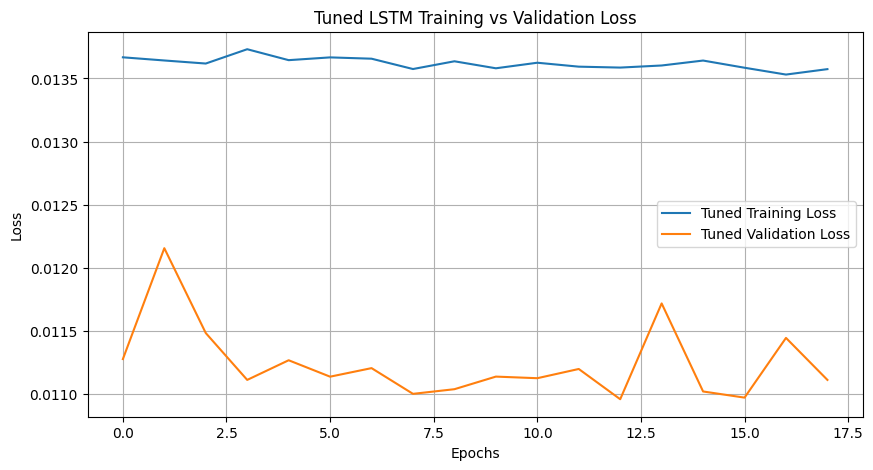

In [ ]:
# Loss graph for the tuned model
plt.figure(figsize=(10, 5))
plt.plot(history_tuned.history['loss'], label='Tuned Training Loss')
plt.plot(history_tuned.history['val_loss'], label='Tuned Validation Loss')
plt.title('Tuned LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

### Hyperparameter Tuning with Keras Tuner

To improve the model's performance, we'll use Keras Tuner to find optimal hyperparameters. We'll define a `build_model` function that takes a `hp` (hyperparameter) object, allowing us to specify the search space for different parameters.

In [ ]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('lstm_units', min_value=32, max_value=256, step=32),
                   input_shape=(train_X.shape[1], train_X.shape[2])))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='mae') # Using MAE as in the untuned model
    return model

# Initialize the Keras Tuner (Hyperband is a good choice)
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=20,
    factor=3,
    hyperband_iterations=1,
    directory='my_dir_pollution',
    project_name='pollution_lstm_tuning')

# Stop training early if validation loss doesn't improve for 5 epochs
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Run the hyperparameter search
tuner.search(train_X, train_y, epochs=50, validation_data=(test_X, test_y), callbacks=[stop_early], verbose=1)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The best hyperparameters are:")
for param, value in best_hps.values.items():
    print(f"  {param}: {value}")

# Build the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Train the best model further (optional, but often recommended)
history_tuned = best_model.fit(train_X, train_y, epochs=50, batch_size=72, validation_data=(test_X, test_y), callbacks=[stop_early], verbose=1)

# Make predictions with the best tuned model
train_predict_tuned = best_model.predict(train_X)
test_predict_tuned = best_model.predict(test_X)

# Inverse transform the predictions and actual values to original scale
# Reshape test_X for inverse scaling
test_X_reshaped = test_X.reshape((test_X.shape[0], test_X.shape[2]))
train_X_reshaped = train_X.reshape((train_X.shape[0], train_X.shape[2]))

inv_test_predict_tuned = np.concatenate((test_predict_tuned, test_X_reshaped[:, 1:]), axis=1)
inv_test_predict_tuned = scaler.inverse_transform(inv_test_predict_tuned)[:, 0]

inv_train_predict_tuned = np.concatenate((train_predict_tuned, train_X_reshaped[:, 1:]), axis=1)
inv_train_predict_tuned = scaler.inverse_transform(inv_train_predict_tuned)[:, 0]

# Calculate RMSE for tuned model
train_rmse_tuned = np.sqrt(mean_squared_error(inv_train_y, inv_train_predict_tuned))
test_rmse_tuned = np.sqrt(mean_squared_error(inv_y, inv_test_predict_tuned))

print(f"\nTuned Model - Train RMSE: {train_rmse_tuned:.3f}")
print(f"Tuned Model - Test RMSE: {test_rmse_tuned:.3f}")

Trial 30 Complete [00h 01m 04s]
val_loss: 0.011180901899933815

Best val_loss So Far: 0.010964823886752129
Total elapsed time: 00h 27m 38s
The best hyperparameters are:
  lstm_units: 256
  dropout_rate: 0.2
  learning_rate: 0.001
  tuner/epochs: 20
  tuner/initial_epoch: 7
  tuner/bracket: 2
  tuner/round: 2
  tuner/trial_id: 0012
Epoch 1/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0137 - val_loss: 0.0113
Epoch 2/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0136 - val_loss: 0.0122
Epoch 3/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0136 - val_loss: 0.0115
Epoch 4/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0137 - val_loss: 0.0111
Epoch 5/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.0136 - val_loss: 0.0113
Epoch 6/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0137 - val_loss: 0.0111
Epoch 7/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0137 - val_loss: 0.0112
Epoch 8/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - l

### Visualizing Tuned Model Performance

Let's visualize the predictions of the tuned model against the original data to see the improvement.

In [ ]:
# Plotting results for the tuned model
plt.figure(figsize=(15, 6))
plt.plot(inv_y, label='Actual Data') # Use inv_y for original scale actual data
plt.plot(inv_test_predict_tuned, label='Tuned Test Predict', linestyle='--')

plt.title('LSTM Model Prediction (With Hyperparameter Tuning)')
plt.xlabel('Time')
plt.ylabel('PM2.5') # Updated label for pollution data
plt.legend()
plt.show()

### Comparison and Summary

Finally, let's compare the performance of the untuned and tuned models.

In [ ]:
print(f"--- Model Performance Comparison ---")
print(f"Untuned Model - Train RMSE: {train_rmse_untuned:.3f}")
print(f"Untuned Model - Test RMSE: {test_rmse_untuned:.3f}")
print(f"\nTuned Model - Train RMSE: {train_rmse_tuned:.3f}")
print(f"Tuned Model - Test RMSE: {test_rmse_tuned:.3f}")

# Provide a concluding summary
print("\nSummary:")
print("The initial LSTM model provides a baseline for time series prediction. ")
print("Hyperparameter tuning with Keras Tuner helps optimize the model's architecture ")
print("and learning parameters, potentially leading to better predictive accuracy (lower RMSE) ")
print("and generalization on unseen data. The plots visualize how well each model fits the data.")

--- Model Performance Comparison ---
Untuned Model - Train RMSE: 25.172
Untuned Model - Test RMSE: 20.525

Tuned Model - Train RMSE: 24.514
Tuned Model - Test RMSE: 19.800

Summary:
The initial LSTM model provides a baseline for time series prediction. 
Hyperparameter tuning with Keras Tuner helps optimize the model's architecture 
and learning parameters, potentially leading to better predictive accuracy (lower RMSE) 
and generalization on unseen data. The plots visualize how well each model fits the data.
